In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
df = pd.read_excel('/content/drive/MyDrive/IT24101462.xlsx',  index_col="Date")

In [58]:
# Calculate Log_Close as the natural logarithm of Close*
df['Log_Close'] = np.log(df['Close*'])

In [59]:
# Normalization
cols = ['Open','High','Low','Close*','Adj Close**','Volume']
scaler = MinMaxScaler()

In [60]:
# Scale selected columns
scaled = scaler.fit_transform(df[cols])

In [61]:
#Add scaled columns to the DataFrame
for i, col in enumerate(cols):
    df[col + "_scaled"] = scaled[:, i]

In [62]:
print(df.head())

                Open      High       Low    Close*  Adj Close**     Volume  \
Date                                                                         
2018-05-01  24117.29  24117.29  23808.19  24099.05     24099.05  380070000   
2018-05-02  24097.63  24185.52  23886.30  23924.98     23924.98  385350000   
2018-05-03  23836.23  23996.15  23531.31  23930.15     23930.15  389240000   
2018-05-04  23865.22  24333.35  23778.87  24262.51     24262.51  329480000   
2018-05-07  24317.66  24479.45  24263.42  24357.32     24357.32  307670000   

            Log_Close  Open_scaled  High_scaled  Low_scaled  Close*_scaled  \
Date                                                                         
2018-05-01  10.089928     0.207370     0.172171    0.193269       0.199011   
2018-05-02  10.082678     0.206134     0.176571    0.198181       0.188033   
2018-05-03  10.082894     0.189697     0.164358    0.175856       0.188359   
2018-05-04  10.096688     0.191519     0.186106    0.191425    

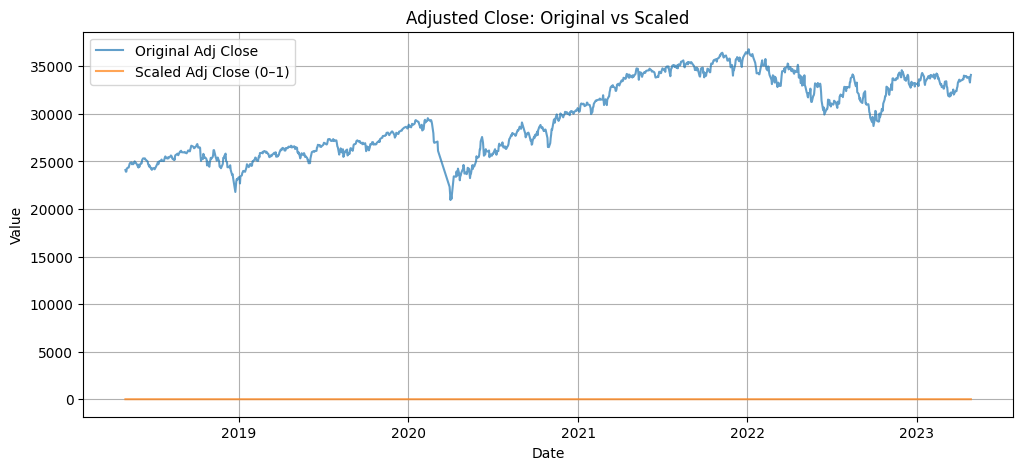

In [63]:
#EDA after Scaling
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Adj Close**'], label="Original Adj Close", alpha=0.7)
plt.plot(df.index, df['Adj Close**_scaled'], label="Scaled Adj Close (0–1)", alpha=0.7)
plt.title("Adjusted Close: Original vs Scaled")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()



In [64]:
# Save preprocessed dataset as Excel
df.to_excel("IT24101452.xlsx")
print("Preprocessed dataset saved as 'IT24101452.xlsx'")

Preprocessed dataset saved as 'IT24101452.xlsx'
